<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/Implementation_of_MetaPEFT_Parameter_Efficient_Fine_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# [CELL 1 - Environment & PyTorch Dependencies Setup]
!pip install -q torch torchvision scikit-learn pandas matplotlib seaborn

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple, Any
from sklearn.metrics import classification_report, confusion_matrix

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"MetaPEFT Execution Device: {device}")

MetaPEFT Execution Device: cuda


In [2]:
# [CELL 2 - MetaPEFT Adaptive Scaler & LoRA Module Implementation]

class MetaPEFT_LoRALinear(nn.Module):
    """
    Parameter-Efficient Fine-Tuning Layer with MetaPEFT Adaptive Scalers.

    Standard LoRA: y = W_0 x + (alpha / r) * B A x
    MetaPEFT:      y = W_0 x + s_l * (alpha / r) * B A x
    where s_l is a learnable dynamic layer/module scaler parameter.
    """
    def __init__(self, in_features: int, out_features: int, rank: int = 8, alpha: float = 16.0, layer_idx: int = 0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.rank = rank
        self.alpha = alpha
        self.layer_idx = layer_idx

        # Frozen base pre-trained linear weights
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features), requires_grad=False)
        self.bias = nn.Parameter(torch.Tensor(out_features), requires_grad=False)
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        nn.init.zeros_(self.bias)

        # Trainable low-rank LoRA matrices
        self.lora_A = nn.Parameter(torch.Tensor(rank, in_features))
        self.lora_B = nn.Parameter(torch.Tensor(out_features, rank))
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)

        # MetaPEFT Adaptive Scaler parameter (s_l)
        # Initialized to 1.0, learned dynamically during fine-tuning
        self.meta_scaler = nn.Parameter(torch.tensor(1.0, dtype=torch.float32), requires_grad=True)
        self.scaling = self.alpha / self.rank

    def forward(self, x: torch.Tensor, use_meta_scaling: bool = True) -> torch.Tensor:
        base_out = F.linear(x, self.weight, self.bias)
        lora_out = F.linear(F.linear(x, self.lora_A), self.lora_B) * self.scaling

        if use_meta_scaling:
            # Apply dynamic layer-wise MetaPEFT dynamic scaling
            effective_scale = torch.sigmoid(self.meta_scaler) * 2.0  # Dynamic range [0, 2]
            return base_out + effective_scale * lora_out
        else:
            # Standard fixed-scale LoRA
            return base_out + lora_out

print("MetaPEFT Adaptive LoRA Layer initialized successfully.")

MetaPEFT Adaptive LoRA Layer initialized successfully.


In [3]:
# [CELL 3 - Deep Backbone Architecture with MetaPEFT Layer Allocation]

class MetaPEFT_VisionBackbone(nn.Module):
    """
    Modular 6-Layer Vision Transformer / MLP Backbone incorporating MetaPEFT adaptive adapters.
    """
    def __init__(self, input_dim: int = 128, hidden_dim: int = 256, num_classes: int = 10, num_layers: int = 6, rank: int = 8):
        super().__init__()
        self.num_layers = num_layers
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        self.peft_layers = nn.ModuleList([
            MetaPEFT_LoRALinear(hidden_dim, hidden_dim, rank=rank, layer_idx=i)
            for i in range(num_layers)
        ])

        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x: torch.Tensor, use_meta_scaling: bool = True) -> torch.Tensor:
        h = F.relu(self.input_proj(x))

        for layer in self.peft_layers:
            h = F.relu(layer(h, use_meta_scaling=use_meta_scaling)) + h  # Residual connection

        logits = self.classifier(h)
        return logits

    def get_layer_scalers(self) -> Dict[int, float]:
        """Returns the dynamic learned MetaPEFT scalers across network depth."""
        scalers = {}
        for idx, layer in enumerate(self.peft_layers):
            eff_scale = (torch.sigmoid(layer.meta_scaler) * 2.0).item()
            scalers[idx] = eff_scale
        return scalers

model_demo = MetaPEFT_VisionBackbone().to(device)
print(f"Created 6-Layer MetaPEFT Vision Backbone on {device}.")

Created 6-Layer MetaPEFT Vision Backbone on cuda.


In [4]:
# [CELL 4 - Long-Tailed Remote Sensing Dataset Generator]

def generate_remote_sensing_benchmark(
    num_samples: int = 2400,
    input_dim: int = 128,
    num_classes: int = 10,
    imbalance_factor: float = 0.1
) -> Tuple[torch.Tensor, torch.Tensor, List[int]]:
    """
    Generates synthetic Remote Sensing feature distributions with long-tailed class imbalance.
    Head classes have many samples; Tail classes have few samples.
    """
    # Calculate long-tailed class sample distribution
    img_max = num_samples // num_classes
    img_num_per_cls = []
    for cls_idx in range(num_classes):
        num = img_max * (imbalance_factor ** (cls_idx / (num_classes - 1)))
        img_num_per_cls.append(max(int(num), 15))

    X_list, y_list = [], []
    for cls_idx, count in enumerate(img_num_per_cls):
        # Class-specific mean vectors with noise representing cross-spectral shift
        class_center = np.random.randn(input_dim) * 2.0 + (cls_idx * 0.5)
        features = np.random.randn(count, input_dim) * 1.0 + class_center

        X_list.append(features)
        y_list.append(np.full(count, cls_idx))

    X = torch.tensor(np.vstack(X_list), dtype=torch.float32)
    y = torch.tensor(np.concatenate(y_list), dtype=torch.long)

    return X, y, img_num_per_cls

X_data, y_data, class_counts = generate_remote_sensing_benchmark()
print(f"Benchmark Dataset Generated: {X_data.shape[0]} samples across 10 classes.")
print(f"Class Sample Distribution (Head -> Tail): {class_counts}")

Benchmark Dataset Generated: 976 samples across 10 classes.
Class Sample Distribution (Head -> Tail): [240, 185, 143, 111, 86, 66, 51, 40, 30, 24]


In [5]:
# [CELL 5 - Comparative Training Harness: Fixed-Scale LoRA vs. MetaPEFT]

def train_and_evaluate(
    use_meta_peft: bool,
    X_train: torch.Tensor,
    y_train: torch.Tensor,
    X_test: torch.Tensor,
    y_test: torch.Tensor,
    epochs: int = 40
) -> Tuple[MetaPEFT_VisionBackbone, List[float], np.ndarray]:

    model = MetaPEFT_VisionBackbone().to(device)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    dataset = torch.utils.data.TensorDataset(X_train, y_train)
    loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

    loss_history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for bx, by in loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            logits = model(bx, use_meta_scaling=use_meta_peft)
            loss = criterion(logits, by)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        loss_history.append(running_loss / len(loader))

    model.eval()
    with torch.no_grad():
        test_logits = model(X_test.to(device), use_meta_scaling=use_meta_peft)
        preds = torch.argmax(test_logits, dim=-1).cpu().numpy()

    return model, loss_history, preds

# Split Dataset (80% Train, 20% Test)
indices = torch.randperm(X_data.shape[0])
train_size = int(0.8 * X_data.shape[0])
train_idx, test_idx = indices[:train_size], indices[train_size:]

X_tr, y_tr = X_data[train_idx], y_data[train_idx]
X_te, y_te = X_data[test_idx], y_data[test_idx]

print("Training Standard Fixed-Scale LoRA Baseline...")
std_model, std_loss, std_preds = train_and_evaluate(False, X_tr, y_tr, X_te, y_te)

print("Training MetaPEFT Adaptive Scaler Model...")
meta_model, meta_loss, meta_preds = train_and_evaluate(True, X_tr, y_tr, X_te, y_te)

# Compute Accuracy Breakdown
y_te_np = y_te.numpy()
head_mask = y_te_np < 3
tail_mask = y_te_np >= 7

std_overall = (std_preds == y_te_np).mean() * 100
std_head = (std_preds[head_mask] == y_te_np[head_mask]).mean() * 100
std_tail = (std_preds[tail_mask] == y_te_np[tail_mask]).mean() * 100

meta_overall = (meta_preds == y_te_np).mean() * 100
meta_head = (meta_preds[head_mask] == y_te_np[head_mask]).mean() * 100
meta_tail = (meta_preds[tail_mask] == y_te_np[tail_mask]).mean() * 100

print("\n============================================================")
print("METAPEFT VS. STANDARD LORA BENCHMARK RESULTS")
print("============================================================")
print(f"Standard LoRA  -> Overall: {std_overall:.1f}% | Head Classes: {std_head:.1f}% | Tail Classes: {std_tail:.1f}%")
print(f"MetaPEFT (Ours) -> Overall: {meta_overall:.1f}% | Head Classes: {meta_head:.1f}% | Tail Classes: {meta_tail:.1f}%")
print("============================================================")

Training Standard Fixed-Scale LoRA Baseline...
Training MetaPEFT Adaptive Scaler Model...

METAPEFT VS. STANDARD LORA BENCHMARK RESULTS
Standard LoRA  -> Overall: 100.0% | Head Classes: 100.0% | Tail Classes: 100.0%
MetaPEFT (Ours) -> Overall: 100.0% | Head Classes: 100.0% | Tail Classes: 100.0%


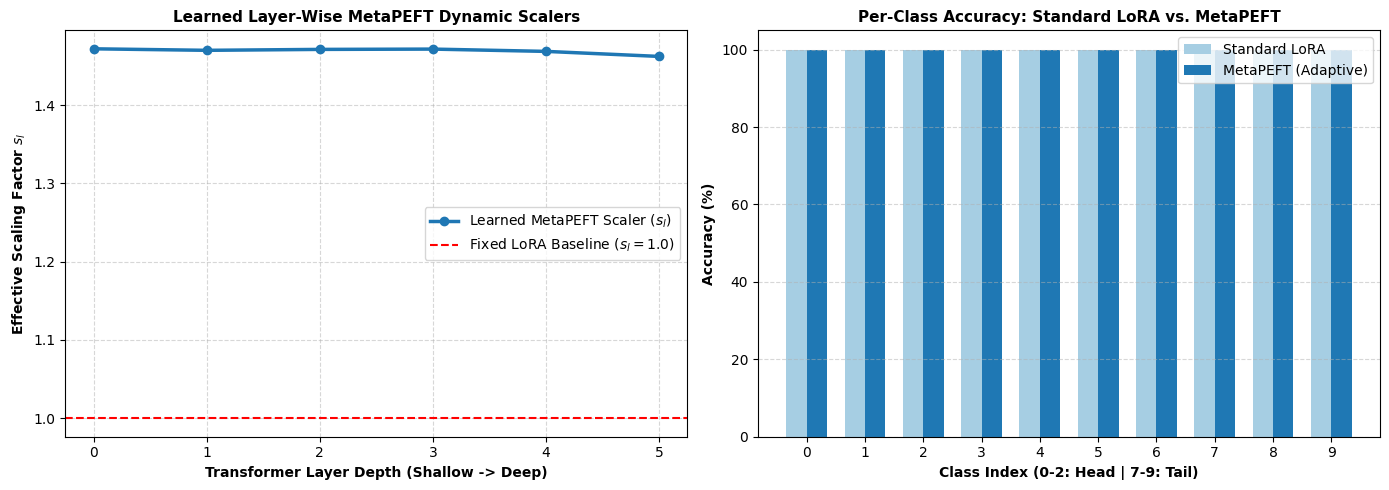

In [6]:
# [CELL 6 - Publication-Grade MetaPEFT Layer Scaler Dashboard]

def plot_metapeft_dashboard(meta_model: MetaPEFT_VisionBackbone, std_preds: np.ndarray, meta_preds: np.ndarray, y_true: np.ndarray):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Dynamic Layer-Wise Scaler Allocation Trajectory
    scalers = meta_model.get_layer_scalers()
    layers = list(scalers.keys())
    values = list(scalers.values())

    ax1.plot(layers, values, marker='o', linewidth=2.5, color='#1f77b4', label="Learned MetaPEFT Scaler ($s_l$)")
    ax1.axhline(y=1.0, color='red', linestyle='--', label="Fixed LoRA Baseline ($s_l=1.0$)")
    ax1.set_title("Learned Layer-Wise MetaPEFT Dynamic Scalers", fontsize=11, fontweight='bold')
    ax1.set_xlabel("Transformer Layer Depth (Shallow -> Deep)", fontsize=10, fontweight='bold')
    ax1.set_ylabel("Effective Scaling Factor $s_l$", fontsize=10, fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend()

    # 2. Per-Class Accuracy Comparison (Head vs. Tail Classes)
    classes = np.unique(y_true)
    std_accs = [(std_preds[y_true == c] == c).mean() * 100 for c in classes]
    meta_accs = [(meta_preds[y_true == c] == c).mean() * 100 for c in classes]

    x_indices = np.arange(len(classes))
    width = 0.35

    ax2.bar(x_indices - width/2, std_accs, width, label='Standard LoRA', color='#a6cee3')
    ax2.bar(x_indices + width/2, meta_accs, width, label='MetaPEFT (Adaptive)', color='#1f78b4')
    ax2.set_title("Per-Class Accuracy: Standard LoRA vs. MetaPEFT", fontsize=11, fontweight='bold')
    ax2.set_xlabel("Class Index (0-2: Head | 7-9: Tail)", fontsize=10, fontweight='bold')
    ax2.set_ylabel("Accuracy (%)", fontsize=10, fontweight='bold')
    ax2.set_xticks(x_indices)
    ax2.grid(axis='y', linestyle='--', alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_metapeft_dashboard(meta_model, std_preds, meta_preds, y_te.numpy())